# Unidade III — Pré-processamento de Dados

## Redução de dados

**Carga estimada:** 2 horas  
**Pré-requisitos:** álgebra linear básica, variância, pandas e NumPy.

> **Pergunta norteadora:** quanto podemos reduzir linhas ou atributos preservando a informação necessária à tarefa?


## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- distinguir redução de linhas, de granularidade e de atributos;
- aplicar amostragem, prototipagem por agrupamento e agregação com finalidade declarada;
- realizar seleção de atributos preservando os nomes das colunas originais;
- interpretar componentes principais e variância explicada;
- medir o compromisso entre compressão e perda de informação.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")


## Quatro formas de reduzir

Antes de escolher uma técnica, identifique **qual eixo será reduzido**. Linhas representam objetos; colunas representam atributos; granularidade determina quanto detalhe existe em cada linha.

| Forma | O que diminui? | Resultado | Exemplo |
|---|---|---|---|
| Amostragem | número de linhas | subconjunto de objetos originais | manter 20% dos pacientes |
| Agregação | número de linhas ou resolução | resumos por grupo ou período | uma linha por mês em vez de uma por dia |
| Seleção de atributos | número de colunas | subconjunto das colunas originais | manter 8 das 30 medidas |
| Extração de atributos | número de dimensões | novas colunas derivadas | substituir 30 medidas por 7 componentes |

As formas não são intercambiáveis. Amostragem e agregação reduzem principalmente linhas; seleção e extração reduzem colunas. A técnica deve preservar o que a pergunta exige.


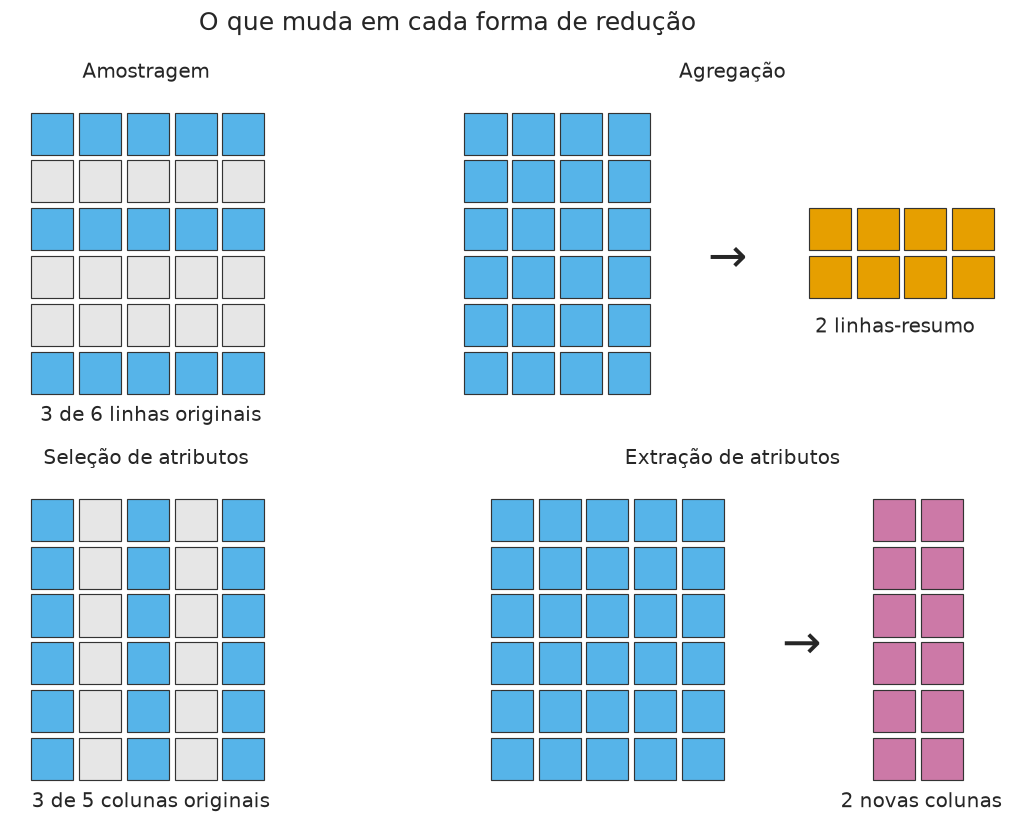

In [2]:
def desenhar_grade(ax, linhas, colunas, x0=0, y0=0, linhas_mantidas=None,
                   colunas_mantidas=None, cor="#56B4E9"):
    """Desenha uma tabela esquemática; não representa valores da base."""
    linhas_mantidas = set(range(linhas)) if linhas_mantidas is None else set(linhas_mantidas)
    colunas_mantidas = set(range(colunas)) if colunas_mantidas is None else set(colunas_mantidas)
    for linha in range(linhas):
        for coluna in range(colunas):
            mantida = linha in linhas_mantidas and coluna in colunas_mantidas
            ax.add_patch(plt.Rectangle(
                (x0 + coluna, y0 + linhas - 1 - linha), 0.88, 0.88,
                facecolor=cor if mantida else "#E6E6E6",
                edgecolor="#333333", linewidth=0.7,
            ))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), dpi=120)

desenhar_grade(axes[0, 0], 6, 5, linhas_mantidas=[0, 2, 5])
axes[0, 0].set(title="Amostragem", xlim=(-0.4, 5.2), ylim=(-0.4, 6.4))
axes[0, 0].text(2.5, -0.25, "3 de 6 linhas originais", ha="center", va="top")

desenhar_grade(axes[0, 1], 6, 4, x0=0)
axes[0, 1].text(5.5, 2.8, "→", fontsize=28, ha="center", va="center")
desenhar_grade(axes[0, 1], 2, 4, x0=7.2, y0=2, cor="#E69F00")
axes[0, 1].set(title="Agregação", xlim=(-0.4, 11.6), ylim=(-0.4, 6.4))
axes[0, 1].text(9, 1.6, "2 linhas-resumo", ha="center", va="top")

desenhar_grade(axes[1, 0], 6, 5, colunas_mantidas=[0, 2, 4])
axes[1, 0].set(title="Seleção de atributos", xlim=(-0.4, 5.2), ylim=(-0.4, 6.4))
axes[1, 0].text(2.5, -0.25, "3 de 5 colunas originais", ha="center", va="top")

desenhar_grade(axes[1, 1], 6, 5, x0=0)
axes[1, 1].text(6.5, 2.8, "→", fontsize=28, ha="center", va="center")
desenhar_grade(axes[1, 1], 6, 2, x0=8, cor="#CC79A7")
axes[1, 1].set(title="Extração de atributos", xlim=(-0.4, 10.5), ylim=(-0.4, 6.4))
axes[1, 1].text(9, -0.25, "2 novas colunas", ha="center", va="top")

for ax in axes.flat:
    ax.set_aspect("equal")
    ax.axis("off")

fig.suptitle("O que muda em cada forma de redução", fontsize=15)
fig.tight_layout()
plt.show()


A figura deve ser lida pelas formas e rótulos, não apenas pelas cores. Na amostragem, algumas linhas originais permanecem. Na agregação, seis linhas dão origem a duas linhas-resumo. Na seleção, três colunas originais são preservadas com seus significados. Na extração, todas as linhas passam a ser descritas por duas novas colunas derivadas.

### 1. Amostragem — selecionar linhas existentes

Amostragem escolhe parte dos objetos sem alterar suas colunas. É útil para diminuir tempo e memória, fazer exploração inicial ou construir um subconjunto para rotulagem. Pode ser aleatória simples, estratificada ou orientada à cobertura. O risco central é perder casos raros e produzir uma amostra que não represente dimensões relevantes.


In [3]:
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target.rename("diagnostico")
_, X_amostra, _, y_amostra = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
pd.DataFrame({
    "completo": y.value_counts(normalize=True).sort_index(),
    "amostra_estratificada": y_amostra.value_counts(normalize=True).sort_index(),
}).round(3)


,completo,amostra_estratificada
diagnostico,,
0,0.373,0.368
1,0.627,0.632


A base completa possui 569 linhas e a amostra, 114. A estratificação preserva aproximadamente a proporção do diagnóstico porque esse foi o critério usado na seleção. Ela não garante representatividade para idade, local ou período, que nem sequer aparecem neste conjunto. Uma amostra aleatória também não corrige viés da população originalmente coletada.

#### Representantes obtidos por *clustering*

A ideia de formar grupos de linhas e manter um representante de cada grupo é uma técnica legítima de **redução de objetos**. Ela costuma ser chamada de seleção de protótipos, amostragem representativa ou construção de *coreset*. Portanto, fica mais próxima da amostragem do que da seleção de atributos.

- Se guardamos o **centroide**, obtemos um protótipo sintético que pode não corresponder a nenhuma linha real.
- Se guardamos a linha real mais próxima do centroide, obtemos um representante observável, semelhante a um medoide.
- Se sorteamos linhas dentro de cada grupo, temos uma amostragem estratificada pelos grupos descobertos.

No exemplo, o K-means encontra 12 grupos nas linhas padronizadas e, para cada centroide, selecionamos a observação real mais próxima. O alvo diagnóstico não participa do agrupamento.


In [4]:
n_representantes = 12
escala_prototipos = StandardScaler()
X_prototipos_pad = escala_prototipos.fit_transform(X)

kmeans = KMeans(n_clusters=n_representantes, n_init=10, random_state=RANDOM_STATE)
rotulos_cluster = kmeans.fit_predict(X_prototipos_pad)
indices_representantes, distancias = pairwise_distances_argmin_min(
    kmeans.cluster_centers_, X_prototipos_pad
)

resumo_representantes = pd.DataFrame({
    "cluster": np.arange(n_representantes),
    "tamanho_do_grupo": np.bincount(rotulos_cluster, minlength=n_representantes),
    "indice_da_linha_real": X.index.to_numpy()[indices_representantes],
    "distancia_ao_centroide": distancias,
}).sort_values("tamanho_do_grupo", ascending=False)

resumo_representantes.round(3)


,cluster,tamanho_do_grupo,indice_da_linha_real,distancia_ao_centroide
1,1,96,249,0.964
11,11,78,125,1.249
7,7,70,516,1.768
4,4,67,361,1.306
8,8,66,423,1.293
9,9,63,110,1.986
6,6,47,512,1.514
3,3,39,300,2.179
0,0,17,176,3.226
2,2,13,118,2.444


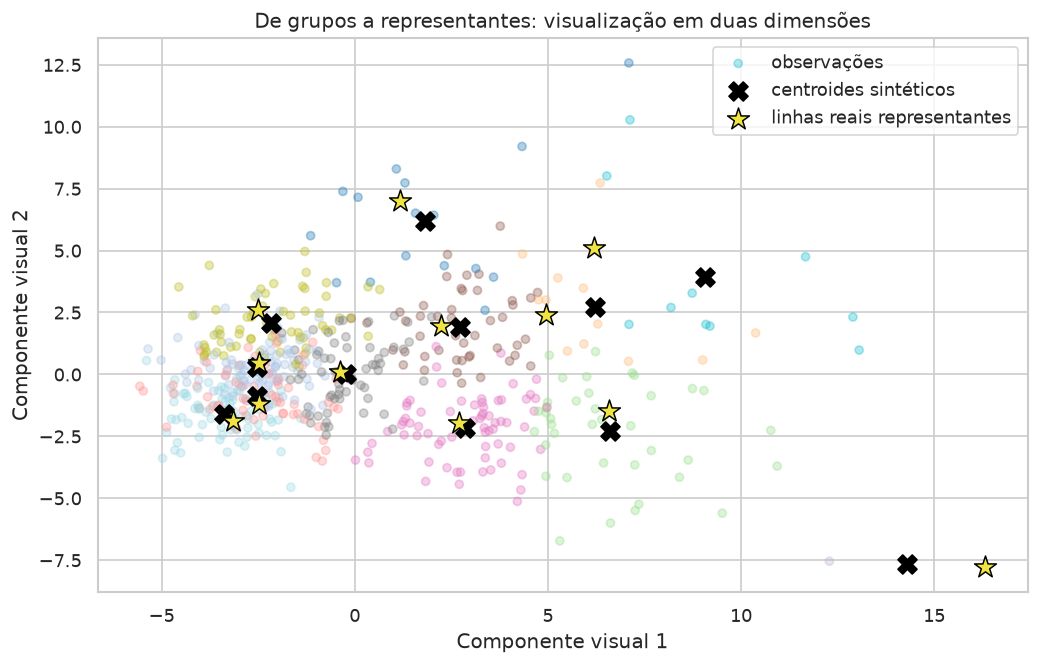

In [5]:
pca_visual = PCA(n_components=2)
X_visual = pca_visual.fit_transform(X_prototipos_pad)
centroides_visuais = pca_visual.transform(kmeans.cluster_centers_)
representantes_visuais = X_visual[indices_representantes]

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
ax.scatter(
    X_visual[:, 0], X_visual[:, 1], c=rotulos_cluster, cmap="tab20",
    s=24, alpha=0.35, label="observações",
)
ax.scatter(
    centroides_visuais[:, 0], centroides_visuais[:, 1],
    marker="X", s=130, c="#000000", label="centroides sintéticos",
)
ax.scatter(
    representantes_visuais[:, 0], representantes_visuais[:, 1],
    marker="*", s=190, c="#F0E442", edgecolors="#000000",
    linewidths=0.9, label="linhas reais representantes",
)
ax.set(
    title="De grupos a representantes: visualização em duas dimensões",
    xlabel="Componente visual 1",
    ylabel="Componente visual 2",
)
ax.legend(loc="best")
plt.show()


Na projeção, os pontos pequenos são as 569 observações, os X pretos são centroides sintéticos e as estrelas são as 12 linhas reais escolhidas. Cada estrela fica próxima do centro do respectivo grupo no espaço original padronizado. A figura usa apenas duas componentes para visualização; proximidades aparentes podem mudar porque o K-means e a escolha dos representantes ocorreram nas 30 dimensões, não neste plano.

O procedimento reduz 569 objetos a 12 linhas reais. Ele procura cobrir regiões diferentes do espaço de atributos, mas não preserva automaticamente proporções, fronteiras entre classes, casos raros ou densidades. O resultado também depende da escala, da distância, do número de grupos e do algoritmo. Se esses representantes forem usados para avaliar um modelo, escala e agrupamento devem ser aprendidos somente no treino.

> **Resposta à questão levantada:** sim, *clustering* pode apoiar a redução por representantes. Ele não corresponde à seleção de atributos, pois não remove colunas; corresponde à redução de linhas por protótipos. O agrupamento será estudado como tarefa própria na Unidade VI. Aqui ele aparece somente como instrumento de redução.

### 2. Agregação — mudar a unidade e resumir linhas

Agregação reúne várias linhas em uma unidade mais ampla e calcula estatísticas como soma, média, mediana, mínimo, máximo ou contagem. Exemplos são transformar transações em totais por cliente ou medidas diárias em médias mensais. Diferentemente da amostragem, ela normalmente cria novas linhas-resumo e altera a granularidade.

A média por diagnóstico abaixo produz apenas duas linhas. Ela serve para descrição dos grupos conhecidos, mas não preserva variação individual nem deve ser usada para treinar e avaliar honestamente um classificador de pacientes: o próprio alvo foi usado para formar os grupos.


In [6]:
dados = X.assign(diagnostico=y)
agregado = dados.groupby("diagnostico")[["mean radius", "mean texture", "mean area"]].agg(["mean", "std", "count"]).round(2)
agregado


mean radius             mean texture             mean area  \
                   mean   std count         mean   std count      mean   
diagnostico                                                              
0                 17.46  3.20   212        21.60  3.78   212    978.38   
1                 12.15  1.78   357        17.91  4.00   357    462.79   

                           
                std count  
diagnostico                
0            367.94   212  
1            134.29   357

O resultado reduz 569 pacientes a duas linhas-resumo. A média facilita comparação, enquanto desvio-padrão e contagem lembram que cada linha representa uma distribuição, não um paciente típico. Ainda assim, são perdidos assimetria, multimodalidade, extremos, correlações individuais e a possibilidade de reconstruir os casos originais.

Uma agregação adequada sempre declara: **chave do grupo**, **janela**, **função de resumo** e **nova unidade de análise**. Somar vendas por mês responde sobre volume mensal; usar a média responde sobre valor médio. Trocar a função pode mudar a conclusão.

### 3. Seleção de atributos — manter algumas colunas originais

Seleção de atributos escolhe um subconjunto das colunas existentes. Se começamos com 30 medidas e mantemos 8, continuamos usando nomes e unidades originais. Isso favorece interpretação e pode reduzir coleta, armazenamento e ajuste do modelo.

Há três famílias comuns:

- **filtros:** ranqueiam atributos por variância, correlação, ANOVA ou informação mútua antes do modelo;
- **métodos de busca (*wrappers*):** avaliam subconjuntos pelo desempenho de um modelo, como eliminação recursiva;
- **métodos embutidos:** selecionam durante o ajuste, como Lasso ou árvores com regularização e limiar documentado.

A seguir, um filtro supervisionado ANOVA é ajustado somente no treino e mantém as oito colunas com maior estatística F. O exemplo torna a seleção visível; não significa que oito seja o melhor número para toda tarefa.


In [7]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

seletor = SelectKBest(score_func=f_classif, k=8)
seletor.fit(X_treino, y_treino)
atributos_selecionados = seletor.get_feature_names_out()

ranking_atributos = (
    pd.DataFrame({"atributo": X.columns, "estatistica_F": seletor.scores_})
    .sort_values("estatistica_F", ascending=False)
    .reset_index(drop=True)
)
ranking_atributos.head(8).round(2)


,atributo,estatistica_F
0,worst concave points,736.82
1,mean concave points,675.65
2,worst perimeter,661.44
3,worst radius,634.14
4,mean perimeter,530.66
5,worst area,499.12
6,mean radius,491.37
7,mean area,441.36


A saída mostra nomes de colunas originais: essa é a marca da **seleção**. O teste não participou do ranqueamento. Como ANOVA avalia cada coluna isoladamente, atributos altamente correlacionados podem ocupar várias posições e interações podem ser ignoradas. O valor de $k$ e o método devem ser escolhidos por validação dentro do treino, preferencialmente no mesmo pipeline do modelo.

### 4. Extração de atributos — criar novas colunas

Extração transforma as colunas originais em uma representação nova e menor. Ao contrário da seleção, os atributos resultantes geralmente combinam várias colunas e deixam de ter a unidade original. A PCA é um exemplo não supervisionado.

#### Análise de Componentes Principais

A Análise de Componentes Principais (PCA) procura direções ortogonais de máxima variância. Para dados centralizados $\mathbf{X}$, a matriz de covariância é

$$\mathbf{S}=\frac{1}{n-1}\mathbf{X}^{\mathsf{T}}\mathbf{X}.$$

Cada componente usa um autovetor $\mathbf{w}_j$ de $\mathbf{S}$, e os escores são

$$\mathbf{z}_j=\mathbf{X}\mathbf{w}_j.$$

Autovalores maiores indicam mais variância capturada. Como variância depende da unidade, padronizamos os atributos antes da PCA. Escala e PCA recebem ajuste somente no treino. A PCA é não supervisionada: maior variância não implica maior utilidade para prever o alvo. Cada componente mistura medidas originais, portanto a compressão pode reduzir interpretabilidade.


In [8]:
escala = StandardScaler()
X_treino_pad = escala.fit_transform(X_treino)
X_teste_pad = escala.transform(X_teste)
pca_total = PCA().fit(X_treino_pad)
variancia_acumulada = np.cumsum(pca_total.explained_variance_ratio_)
componentes_90 = int(np.searchsorted(variancia_acumulada, 0.90) + 1)
pd.Series({"atributos_originais": X.shape[1], "componentes_para_90_porcento": componentes_90, "variancia_acumulada": variancia_acumulada[componentes_90 - 1]}).round(3)


atributos_originais             30.000
componentes_para_90_porcento     7.000
variancia_acumulada              0.914
dtype: float64

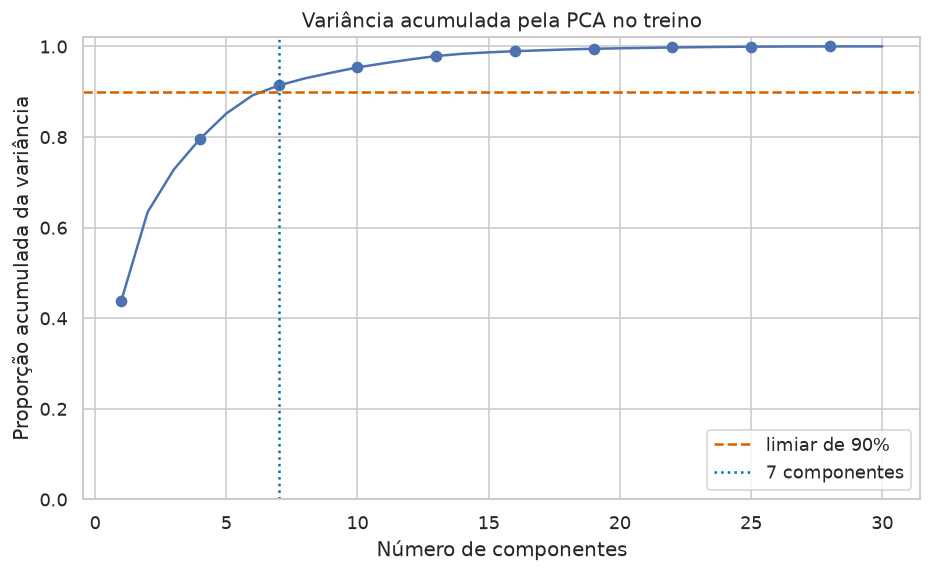

In [9]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
ax.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker="o", markevery=3)
ax.axhline(0.90, color="#D55E00", linestyle="--", label="limiar de 90%")
ax.axvline(componentes_90, color="#0072B2", linestyle=":", label=f"{componentes_90} componentes")
ax.set(title="Variância acumulada pela PCA no treino", xlabel="Número de componentes", ylabel="Proporção acumulada da variância", ylim=(0, 1.02))
ax.legend()
plt.show()


O limiar de 90% é uma decisão de projeto, não uma lei. Para medir a perda no espaço padronizado, reconstruímos o teste a partir dos componentes e calculamos a raiz do erro quadrático médio (RMSE):

$$\operatorname{RMSE}=\sqrt{\frac{1}{nd}\sum_{i=1}^{n}\sum_{j=1}^{d}(x_{ij}-\hat{x}_{ij})^2}.
$$

Aqui, $n$ é o número de objetos, $d$ o número de atributos e $\hat{x}_{ij}$ o valor reconstruído. Menor RMSE significa reconstrução mais fiel, mas a utilidade final ainda deve ser avaliada na tarefa.


In [10]:
resultados = []
for k in [2, 5, 10, componentes_90]:
    pca = PCA(n_components=k).fit(X_treino_pad)
    reconstruido = pca.inverse_transform(pca.transform(X_teste_pad))
    rmse = np.sqrt(np.mean((X_teste_pad - reconstruido) ** 2))
    resultados.append({"componentes": k, "compressao": k / X.shape[1], "rmse_reconstrucao": rmse})
pd.DataFrame(resultados).drop_duplicates("componentes").round(3)


,componentes,compressao,rmse_reconstrucao
0,2,0.067,0.568
1,5,0.167,0.386
2,10,0.333,0.227
3,7,0.233,0.305


A tabela evidencia o compromisso: mais componentes ocupam maior fração da dimensionalidade original e reduzem o erro de reconstrução. Os componentes misturam atributos e podem dificultar explicações; se interpretabilidade for central, seleção de atributos pode ser preferível.

## Como escolher a forma de redução

| Necessidade principal | Forma mais diretamente relacionada | Pergunta de verificação |
|---|---|---|
| processar menos objetos sem mudar suas colunas | amostragem ou representantes por *clustering* | grupos raros e regiões do espaço continuam cobertos? |
| mudar a unidade, por exemplo de evento para cliente | agregação | a função-resumo preserva o fenômeno de interesse? |
| usar menos variáveis mantendo seus significados | seleção de atributos | o método foi ajustado apenas no treino e considera redundância? |
| comprimir variáveis em novas dimensões | extração de atributos | desempenho e reconstrução compensam a perda de interpretação? |

É possível combinar formas: primeiro selecionar atributos, depois obter representantes das linhas; ou agregar eventos por cliente e então aplicar PCA. A ordem muda o objeto analisado e deve ser justificada. Em qualquer fluxo preditivo, decisões aprendidas com os dados — seleção, escala, agrupamento e PCA — ficam dentro do treino e da validação.

> **U03-NB03-V01 — Verifique seu entendimento:** por que selecionar o número de componentes usando o conjunto de teste compromete a avaliação final?

> **U03-NB03-E01 — Exercício:** repita a tabela para limiares de variância acumulada de 80%, 90% e 95%. Informe componentes, taxa de compressão e RMSE no teste; recomende uma configuração e explicite seu critério.

> **U03-NB03-E02 — Atividade integradora da unidade:** construa um pipeline reprodutível para uma base propositalmente problemática. Preserve a base bruta; produza diagnóstico antes/depois; separe treino e teste antes de aprender qualquer parâmetro; trate ausências e categorias; aplique uma transformação ou discretização; compare ao menos duas opções de redução; e entregue código, justificativas, indicadores de qualidade e uma seção sobre perdas, vazamento e limitações.


## Síntese

- Amostragem mantém algumas linhas; agregação cria linhas-resumo e muda a granularidade.
- Representantes obtidos por *clustering* reduzem linhas por prototipagem; não selecionam atributos.
- Seleção preserva nomes das colunas escolhidas; extração cria novas colunas, como componentes principais.
- Preservar a proporção de uma classe não garante representatividade completa.
- Compressão deve ser julgada por cobertura, perda, desempenho, custo e interpretabilidade.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 2, seção 2.5.
- SCIKIT-LEARN DEVELOPERS. *User Guide*: feature selection, clustering, decomposition e PCA. Versão 1.x.
- WOLBERG, William H.; STREET, W. Nick; MANGASARIAN, Olvi L. Breast Cancer Wisconsin (Diagnostic) Data Set. UCI Machine Learning Repository, 1995.
